In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

### Parameter Settings

In [2]:
# Time step width
tau = 25
# Number of time steps
Total_steps = 2000
# Total time
T = Total_steps * tau
# Number of spatial grid points
num_grid = 20
# Spatial grid spacing
delta_x = 1
delta_y = 1
# Scale normalization factor
Lambda = 10**0
# Permeability
mu_0 = 1
# Density
density = 1
# Permittivity
epsilon_0 = 1
# Mass
mass = 1
# Charge
q = -1
# Number of variables
# N = 5 * num_grid
N = 5 * num_grid**2
# Upper bound on total particle number
m = 2
# Size of the Hamiltonian matrix
M = math.comb(m + N, m)
# Number of x-qubits
n_x = math.floor(np.log2(M)) + 1
# Number of ancilla qubits required for U
n_a = 1
eta = 1
T_real = Total_steps * tau / (192 * eta * (m / 2)**(5 / 2))

k = 2 * np.pi / num_grid
x_min = -num_grid / 2
x_max = num_grid / 2
y_min = -num_grid / 2
y_max = num_grid / 2

### Call the QSVT's results

In [3]:
filename = 'output/CaseD/2DKelvin-Helmholtz_ux_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
ux_qsvt = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_uy_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
uy_qsvt = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Ex_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Ex_qsvt = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Ey_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Ey_qsvt = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Bz_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Bz_qsvt = np.load(filename)
#alpha = 1404.0370365485378#numgrid=16
alpha = 2192.757966579987#numgrid=20
#alpha = 3156.749910905202#numgrid=24
#alpha = 4296.0129771684815#numgrid=28

### Call the expm's results

In [4]:
# change the parameters to load the expm results
tau = 500
Total_steps = 100
T = Total_steps*tau
filename = 'output/CaseD/2DKelvin-Helmholtz_ux_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
ux_expm = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_uy_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
uy_expm = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Ex_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Ex_expm = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Ey_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Ey_expm = np.load(filename)
filename = 'output/CaseD/2DKelvin-Helmholtz_Bz_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
Bz_expm = np.load(filename)

### Visualization of |u| distribution and u vector

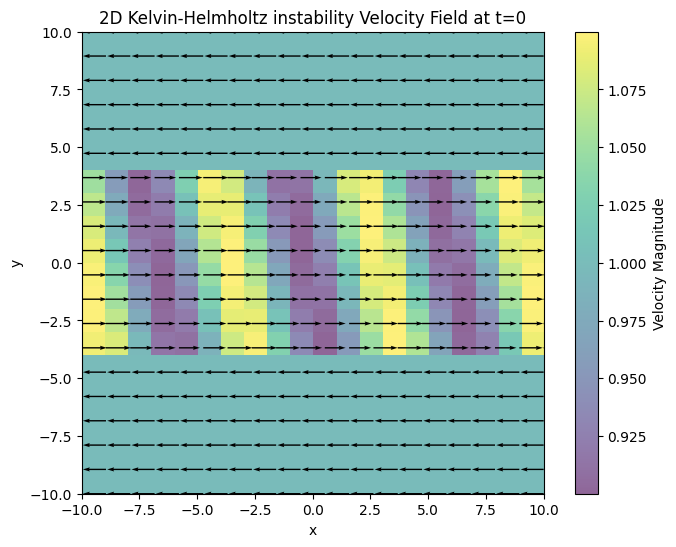

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
step = 0  # time step to display

fig, ax = plt.subplots(figsize=(8, 6))

# Create grid coordinates
Nx, Ny = ux_qsvt.shape[:2]  # get spatial sizes of ux_qsvt, uy_qsvt
x = np.linspace(x_min, x_max, Nx)  # x-coordinates
y = np.linspace(y_min, y_max, Ny)  # y-coordinates
X, Y = np.meshgrid(x, y)  # create mesh grid

# Plot 2D vectors for ux, uy
Q = ax.quiver(X, Y, ux_qsvt[:,:,step].T, uy_qsvt[:,:,step].T, angles='xy', scale_units='xy', scale=1.0)

# Draw a colormap as the background
im = ax.imshow(np.sqrt(ux_qsvt[:,:,step].T**2 + uy_qsvt[:,:,step].T**2), 
               extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', alpha=0.6)

# Add a colorbar
cb = fig.colorbar(im, ax=ax)
cb.set_label('Velocity Magnitude')

# Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# Set aspect ratio to be square
ax.set_aspect('equal', adjustable='box')

# Title
ax.set_title(f'2D Kelvin-Helmholtz instability Velocity Field at t={step*tau/alpha:.3g}')

# Save as PDF
fig.savefig('output/CaseD/2DKH_velocity_vector_field_initial.pdf')

plt.show()


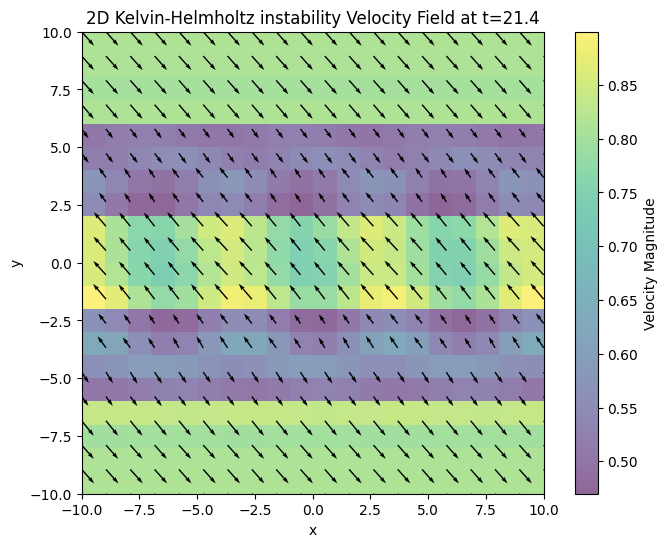

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
step = 94  # time step to display

fig, ax = plt.subplots(figsize=(8, 6))

# Create grid coordinates
Nx, Ny = ux_qsvt.shape[:2]  # spatial sizes of ux_qsvt, uy_qsvt
x = np.linspace(x_min, x_max, Nx)  # x coordinates
y = np.linspace(y_min, y_max, Ny)  # y coordinates
X, Y = np.meshgrid(x, y)  # create mesh grid

# Plot 2D vectors for ux, uy
Q = ax.quiver(X, Y, ux_qsvt[:, :, step].T, uy_qsvt[:, :, step].T, angles='xy', scale_units='xy', scale=1.0)

# Draw a colormap as the background
im = ax.imshow(
    np.sqrt(ux_qsvt[:, :, step].T**2 + uy_qsvt[:, :, step].T**2),
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='viridis',
    alpha=0.6
)

# Add a colorbar
cb = fig.colorbar(im, ax=ax)
cb.set_label('Velocity Magnitude')

# Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# Set aspect ratio to square
ax.set_aspect('equal', adjustable='box')

# Title
ax.set_title(f'2D Kelvin-Helmholtz instability Velocity Field at t={step*tau/alpha:.3g}')

# Save as PDF
fig.savefig('output/CaseD/2DKH_velocity_vector_field_voltex_0.5T.pdf')

plt.show()


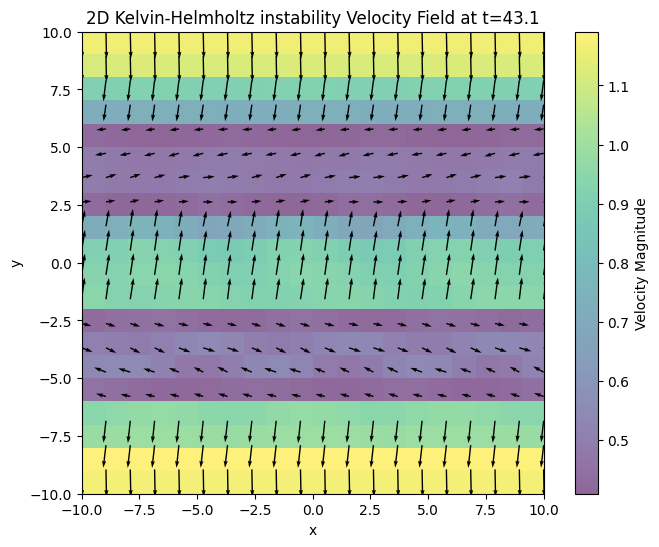

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
step = 189  # time step to display

fig, ax = plt.subplots(figsize=(8, 6))

# Create grid coordinates
Nx, Ny = ux_qsvt.shape[:2]  # spatial sizes of ux_qsvt, uy_qsvt
x = np.linspace(x_min, x_max, Nx)  # x coordinates
y = np.linspace(y_min, y_max, Ny)  # y coordinates
X, Y = np.meshgrid(x, y)  # create mesh grid

# Plot 2D vectors for ux, uy
Q = ax.quiver(X, Y, ux_qsvt[:, :, step].T, uy_qsvt[:, :, step].T, angles='xy', scale_units='xy', scale=1.0)

# Draw a colormap as the background
im = ax.imshow(
    np.sqrt(ux_qsvt[:, :, step].T**2 + uy_qsvt[:, :, step].T**2),
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='viridis',
    alpha=0.6
)

# Add a colorbar
cb = fig.colorbar(im, ax=ax)
cb.set_label('Velocity Magnitude')

# Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# Set aspect ratio to square
ax.set_aspect('equal', adjustable='box')

# Title
ax.set_title(f'2D Kelvin-Helmholtz instability Velocity Field at t={step*tau/alpha:.3g}')

# Save as PDF
fig.savefig('output/CaseD/2DKH_velocity_vector_field_voltex_1.0T.pdf')

plt.show()


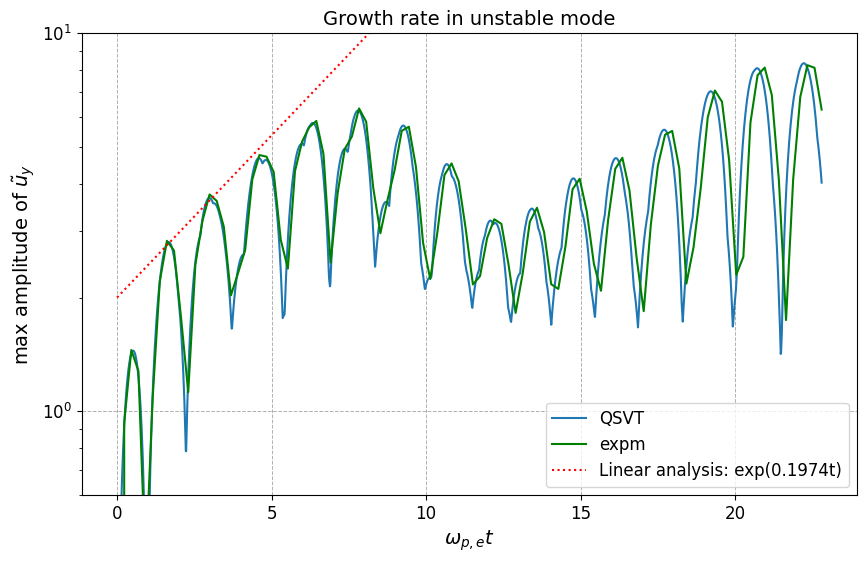

PDF plot for norm evolution in x and v space saved successfully.


In [8]:
# Record time evolution of amplitude
gamma = 0.1974

nt = 2000
uy_amplitude = np.zeros(nt)
for t in range(nt):
    # Get temporal variation
    uy_amplitude[t] = abs(np.max(abs(uy_qsvt[:, :, t])) - np.max(abs(uy_qsvt[:, :, 0])))

nt = 100
uy_amplitude_classical = np.zeros(nt)
for t in range(nt):
    # Get temporal variation
    uy_amplitude_classical[t] = abs(np.max(abs(uy_expm[:, :, t])) - np.max(abs(uy_expm[:, :, 0])))

omega_p = 1
T_real = 2000 * 25 / alpha * omega_p
t_2000 = np.linspace(0, T_real, 2000)
t_100 = np.linspace(0, T_real, 100)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_2000, uy_amplitude, label="QSVT")
ax.plot(t_100, uy_amplitude_classical, label="expm", color="green")
ax.plot(t_2000, 2 * np.exp(gamma * t_2000), label=f"Linear analysis: exp({gamma}t)", linestyle=":", color="red")

# Axis labels and title
ax.set_xlabel(r"$\omega_{p,e}t$", fontsize=14)
ax.set_ylabel(r"max amplitude of $\tilde{u}_{y}$", fontsize=14)
ax.set_title("Growth rate in unstable mode", fontsize=14)
ax.set_yscale('log')

# Customize the plot
tick_size = 12
# y_min, y_max = 10**-7, max(np.sqrt(u_qsvt_m_3_norm**2+E_qsvt_m_3_norm**2))+0.1
ax.set_ylim(6 * 10**-1, 10**1)
ax.grid(True, linestyle='--', linewidth=0.7)
ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=tick_size)

# Save the plot as PDF
plt.savefig('output/CaseD/2DKH_growth_rates_QSVT.pdf', format='pdf')

# Show the plot
plt.show()

print("PDF plot for norm evolution in x and v space saved successfully.")
